In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LassoCV
from sklearn.linear_model import Lasso


import classification_rf

from importlib import reload
reload(classification_rf)

from classification_rf import RandomForestClassifier621

np.random.seed(24)

import rf_wrapper_functions as rfwrap
from collections import namedtuple
Dataset = namedtuple('Dataset', ['X_train', 'X_test', 'y_train', 'y_test'])
Params = namedtuple('Params', ['min_samples_leaf', 'max_features', 'max_depth', 'force_label_split', 'oob_score'])
Data = namedtuple('Data', ['X','y'])


In [3]:
from sklearn.impute import SimpleImputer

#import Cleveland Data
processed_cleveland_data = pd.read_csv("Processed Data/processed.cleveland.data", delimiter=",", na_values=["?"], header = None).to_numpy()
processed_cleveland_data = np.delete(processed_cleveland_data, [11,12], axis=1)

#Fill in missing values
imputer = SimpleImputer(strategy="median")
cleveland = imputer.fit_transform(processed_cleveland_data)

#add label column
cleveland_label = 0
cleveland = np.insert(cleveland, -1, [cleveland_label]*len(cleveland), axis = 1)

#---------------------------

processed_hungarian_data = pd.read_csv("Processed Data/processed.hungarian.data", delimiter=",", na_values=["?"], header = None).to_numpy()
processed_hungarian_data = np.delete(processed_hungarian_data, [11,12], axis=1)
imputer = SimpleImputer(strategy="median")
hungary = imputer.fit_transform(processed_hungarian_data)

#add label column
hungary_label = 1
hungary = np.insert(hungary, -1, [hungary_label]*len(hungary), axis = 1)

#---------------------------

processed_switzerland_data = pd.read_csv("Processed Data/processed.switzerland.data", delimiter=",", na_values=["?"], header = None).to_numpy()
processed_switzerland_data = np.delete(processed_switzerland_data, [11,12], axis=1)
imputer = SimpleImputer(strategy="median")
switzerland = imputer.fit_transform(processed_switzerland_data)

#add label column
switzerland_label = 2
switzerland = np.insert(switzerland, -1, [switzerland_label]*len(switzerland), axis = 1)

#---------------------------

processed_va_data = pd.read_csv("Processed Data/processed.va.data", delimiter=",", na_values=["?"], header = None).to_numpy()
processed_va_data = np.delete(processed_va_data, [11,12], axis=1)
imputer = SimpleImputer(strategy="median")
va = imputer.fit_transform(processed_va_data)

#add label column
va_label = 3
va = np.insert(va, -1, [va_label]*len(va), axis = 1)

#data = np.vstack((processed_cleveland_data, processed_hungarian_data, processed_switzerland_data, processed_va_data))
data = np.vstack((cleveland, hungary, switzerland, va))

labels = [cleveland_label, hungary_label, switzerland_label, va_label]

X = data[:,0:-1]
y = data[:,-1]
y[y != 0] = 1
y = y.astype(int)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=24)

In [13]:
dataset, data = rfwrap.generate_dataset(
   n_datapoints_per_study=45,
   n_studies=3,
   features=20,
   similarity=0.7,
   intercept_sd=.8,
   random_state=0
)

parameters = Params(3, 0.3, 25, False, False)

norm of b: 0.7277
X shape: (45, 20)
Study 0: intercept=-1.04, base_rate=0.27
X @ b range: -1.49 to 1.71
norm of b: 0.7023
X shape: (45, 20)
Study 1: intercept=-0.15, base_rate=0.51
X @ b range: -1.48 to 1.31
norm of b: 0.7932
X shape: (45, 20)
Study 2: intercept=0.86, base_rate=0.69
X @ b range: -1.66 to 1.48


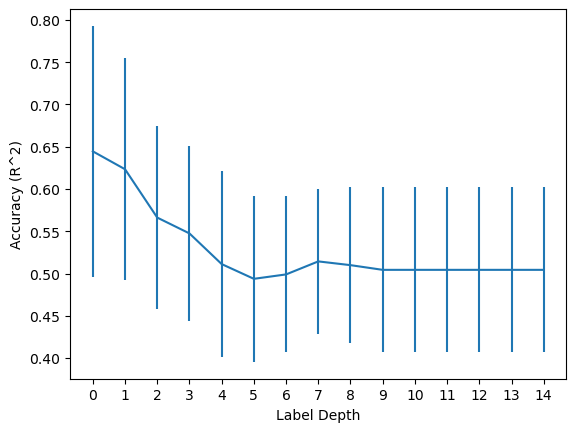

In [14]:
accuracy_score, rf, source_score, source_size, X_tests, y_tests = rfwrap.errorbars_kfold_data(
    n_folds = 10,
    n_estimators=500, 
    depth=15,
    data = data,
    parameters=parameters, 
    metric = "auc", 
    plot=True)

In [ ]:
reload(rfwrap)
accuracy_score, source_score, source_size = rfwrap.evaluate_forests(rf, X_tests, y_tests, metric="score")

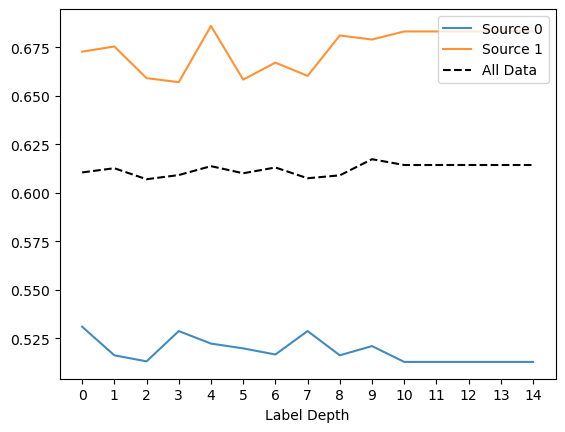

In [43]:
rfwrap.plot_forests(accuracy_score, source_score, sourced=True, show_error = False)